# rMATS single-cell splice-count EDA

This notebook summarizes the full rMATS single-cell output and builds a UMAP colored by cell type.

Run this on a compute node, not a login node. The full sparse count matrices contain ~1.9B observed count entries. The histogram cells use sparse reductions; the UMAP cell defaults to a subsample.

In [1]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse.linalg import LinearOperator
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

ip = get_ipython()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')

try:
    import umap
except ImportError as exc:
    raise ImportError('umap-learn is required for the UMAP cell. Install it in the active environment.') from exc

sns.set_context('notebook')
sns.set_style('whitegrid')

FINAL_DIR = Path('/gpfs/commons/home/nkeung/tabula_muris_data/psi_data/final_data')
H5AD = FINAL_DIR / 'cell_event_counts.h5ad'
INC_NPZ = FINAL_DIR / 'cell_event_inclusion_count.npz'
EXC_NPZ = FINAL_DIR / 'cell_event_exclusion_count.npz'
OBS_NPZ = FINAL_DIR / 'cell_event_count_observed.npz'
PSI_OBS_NPZ = FINAL_DIR / 'cell_event_observed.npz'
PSI_NPZ = FINAL_DIR / 'cell_event_psi.npz'

for path in [H5AD, INC_NPZ, EXC_NPZ, OBS_NPZ, PSI_OBS_NPZ, PSI_NPZ]:
    if not path.exists():
        raise FileNotFoundError(path)


## Metadata and matrix shape

In [2]:
adata_meta = ad.read_h5ad(H5AD, backed='r')
print(adata_meta)
print('obs columns:', list(adata_meta.obs.columns))
print('var columns:', list(adata_meta.var.columns))

obs = adata_meta.obs.copy()
var = adata_meta.var.copy()
adata_meta.file.close()

cell_type_candidates = ['cell_type', 'cell_ontology_class', 'sample_label', 'label']
cell_type_col = next((col for col in cell_type_candidates if col in obs.columns), None)
if cell_type_col is None:
    object_cols = obs.select_dtypes(include='object').columns.tolist()
    cell_type_col = object_cols[0] if object_cols else None
print('Using cell type column:', cell_type_col)

display(obs.head())
display(var.head())

AnnData object with n_obs × n_vars = 107521 × 85497 backed at '/gpfs/commons/home/nkeung/tabula_muris_data/psi_data/final_data/cell_event_counts.h5ad'
    obs: 'cell_index', 'cell_id', 'safe_cell_id', 'cell_type', 'bam_path', 'n_events_observed', 'missing_psi_table'
    var: 'event_index', 'event_id', 'gene_id', 'gene_symbol', 'chromosome', 'exon_strand', 'exon_location', 'exon_length'
    uns: 'X_name'
    layers: 'count_observed', 'exclusion_count', 'psi', 'psi_observed'
obs columns: ['cell_index', 'cell_id', 'safe_cell_id', 'cell_type', 'bam_path', 'n_events_observed', 'missing_psi_table']
var columns: ['event_index', 'event_id', 'gene_id', 'gene_symbol', 'chromosome', 'exon_strand', 'exon_location', 'exon_length']
Using cell type column: cell_type


,cell_index,cell_id,safe_cell_id,cell_type,bam_path,n_events_observed,missing_psi_table
safe_cell_id,,,,,,,
A1-B000971-3_39_F-1-1,0,A1-B000971-3_39_F-1-1,A1-B000971-3_39_F-1-1,B cell,/gpfs/commons/projects/knowles_singlecell_spli...,17819,False
A1-MAA000508-3_9_M-1-1,1,A1-MAA000508-3_9_M-1-1,A1-MAA000508-3_9_M-1-1,B cell,/gpfs/commons/projects/knowles_singlecell_spli...,17824,False
A1-MAA000559-3_8_M-1-1,2,A1-MAA000559-3_8_M-1-1,A1-MAA000559-3_8_M-1-1,B cell,/gpfs/commons/projects/knowles_singlecell_spli...,17812,False
A1-MAA000776-3_10_M-1-1,3,A1-MAA000776-3_10_M-1-1,A1-MAA000776-3_10_M-1-1,B cell,/gpfs/commons/projects/knowles_singlecell_spli...,17812,False
A1-MAA000779-3_11_M-1-1,4,A1-MAA000779-3_11_M-1-1,A1-MAA000779-3_11_M-1-1,B cell,/gpfs/commons/projects/knowles_singlecell_spli...,17816,False


,event_index,event_id,gene_id,gene_symbol,chromosome,exon_strand,exon_location,exon_length
event_id,,,,,,,,
ENSMUSG00000025903.14|chr1|+|4830268-4830315,0,ENSMUSG00000025903.14|chr1|+|4830268-4830315,ENSMUSG00000025903.14,Lypla1,chr1,+,chr1:4830268-4830315,48
ENSMUSG00000025903.14|chr1|+|4839387-4839488,1,ENSMUSG00000025903.14|chr1|+|4839387-4839488,ENSMUSG00000025903.14,Lypla1,chr1,+,chr1:4839387-4839488,102
ENSMUSG00000033793.12|chr1|+|5084417-5084563,2,ENSMUSG00000033793.12|chr1|+|5084417-5084563,ENSMUSG00000033793.12,Atp6v1h,chr1,+,chr1:5084417-5084563,147
ENSMUSG00000033793.12|chr1|+|5101070-5101123,3,ENSMUSG00000033793.12|chr1|+|5101070-5101123,ENSMUSG00000033793.12,Atp6v1h,chr1,+,chr1:5101070-5101123,54
ENSMUSG00000033793.12|chr1|+|5135812-5135937,4,ENSMUSG00000033793.12|chr1|+|5135812-5135937,ENSMUSG00000033793.12,Atp6v1h,chr1,+,chr1:5135812-5135937,126


## Sparse count summaries

These reductions keep the matrices sparse. `count_observed` records which cell-event pairs have rMATS count observations; inclusion/exclusion counts are stored separately.

In [3]:
inc = sp.load_npz(INC_NPZ).tocsr()
exc = sp.load_npz(EXC_NPZ).tocsr()
count_obs = sp.load_npz(OBS_NPZ).tocsr()

print('inclusion:', inc.shape, 'nnz=', inc.nnz)
print('exclusion:', exc.shape, 'nnz=', exc.nnz)
print('count observed:', count_obs.shape, 'nnz=', count_obs.nnz)

events_per_cell = count_obs.getnnz(axis=1)
cells_per_event = count_obs.getnnz(axis=0)
inc_per_cell = np.asarray(inc.sum(axis=1)).ravel()
exc_per_cell = np.asarray(exc.sum(axis=1)).ravel()
total_count_per_cell = inc_per_cell + exc_per_cell
inc_per_event = np.asarray(inc.sum(axis=0)).ravel()
exc_per_event = np.asarray(exc.sum(axis=0)).ravel()
total_count_per_event = inc_per_event + exc_per_event

summary = pd.DataFrame({
    'metric': [
        'events_per_cell', 'cells_per_event', 'total_count_per_cell', 'total_count_per_event',
        'inclusion_count_per_cell', 'exclusion_count_per_cell',
    ],
    'min': [events_per_cell.min(), cells_per_event.min(), total_count_per_cell.min(), total_count_per_event.min(), inc_per_cell.min(), exc_per_cell.min()],
    'median': [np.median(events_per_cell), np.median(cells_per_event), np.median(total_count_per_cell), np.median(total_count_per_event), np.median(inc_per_cell), np.median(exc_per_cell)],
    'mean': [events_per_cell.mean(), cells_per_event.mean(), total_count_per_cell.mean(), total_count_per_event.mean(), inc_per_cell.mean(), exc_per_cell.mean()],
    'max': [events_per_cell.max(), cells_per_event.max(), total_count_per_cell.max(), total_count_per_event.max(), inc_per_cell.max(), exc_per_cell.max()],
})
display(summary)

inclusion: (107521, 85497) nnz= 1917789986
exclusion: (107521, 85497) nnz= 1917789986
count observed: (107521, 85497) nnz= 1917789986


,metric,min,median,mean,max
0,events_per_cell,17812.0,17826.0,17836.422522,19052.0
1,cells_per_event,1.0,8.0,22431.079289,107521.0
2,total_count_per_cell,0.0,82849.0,132839.250000,14683804.0
3,total_count_per_event,0.0,317.0,167057.828125,377888384.0
4,inclusion_count_per_cell,0.0,65516.0,106230.593750,12411399.0
5,exclusion_count_per_cell,0.0,16926.0,26608.658203,2758221.0


## Histograms

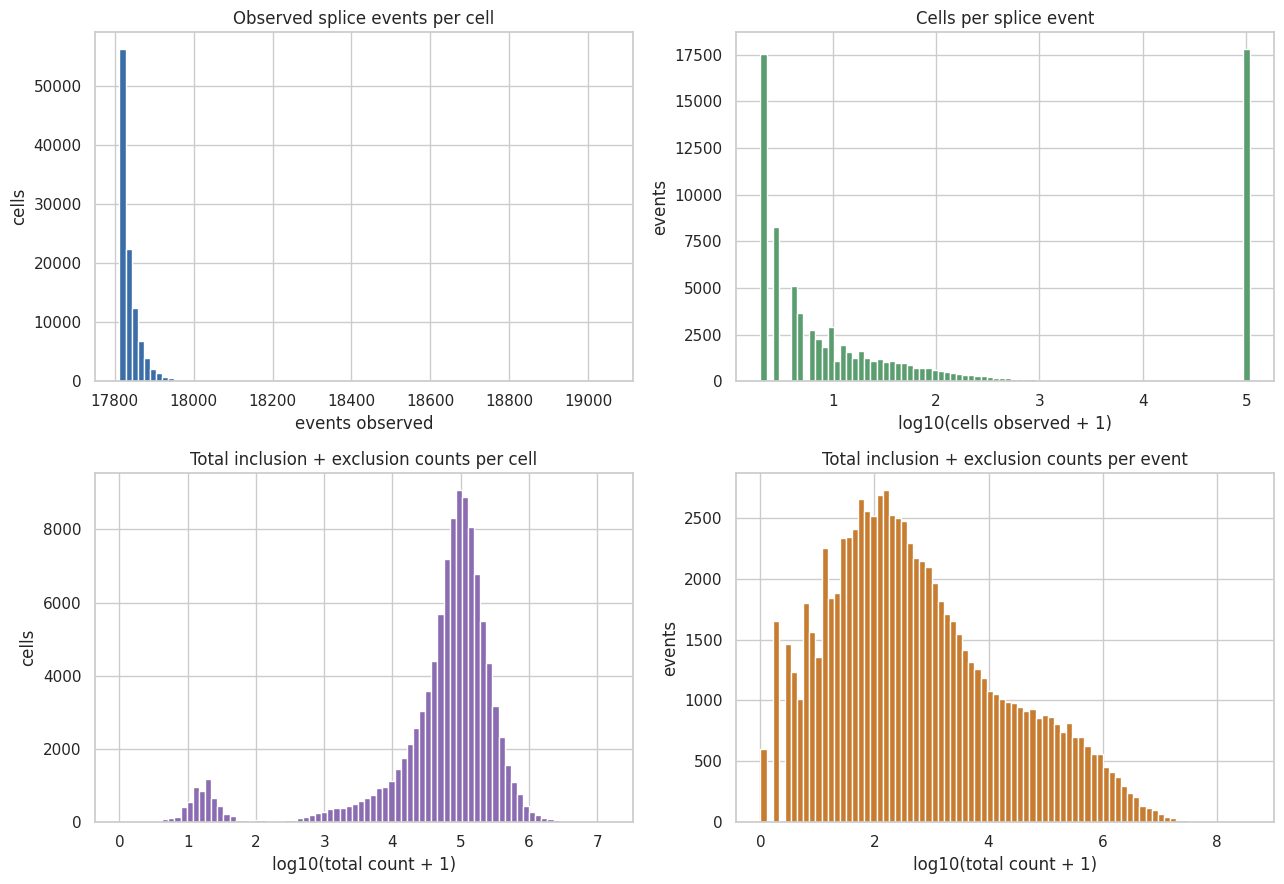

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].hist(events_per_cell, bins=80, color='#3b6ea8')
axes[0, 0].set_title('Observed splice events per cell')
axes[0, 0].set_xlabel('events observed')
axes[0, 0].set_ylabel('cells')

axes[0, 1].hist(np.log10(cells_per_event + 1), bins=80, color='#5a9e6f')
axes[0, 1].set_title('Cells per splice event')
axes[0, 1].set_xlabel('log10(cells observed + 1)')
axes[0, 1].set_ylabel('events')

axes[1, 0].hist(np.log10(total_count_per_cell + 1), bins=80, color='#8b6bb1')
axes[1, 0].set_title('Total inclusion + exclusion counts per cell')
axes[1, 0].set_xlabel('log10(total count + 1)')
axes[1, 0].set_ylabel('cells')

axes[1, 1].hist(np.log10(total_count_per_event + 1), bins=80, color='#c77c2f')
axes[1, 1].set_title('Total inclusion + exclusion counts per event')
axes[1, 1].set_xlabel('log10(total count + 1)')
axes[1, 1].set_ylabel('events')

plt.tight_layout()
plt.show()

## Cell-type QC summaries

In [5]:
cell_qc = pd.DataFrame({
    'events_per_cell': events_per_cell,
    'total_count': total_count_per_cell,
    'inclusion_count': inc_per_cell,
    'exclusion_count': exc_per_cell,
}, index=obs.index)
if cell_type_col is not None:
    cell_qc[cell_type_col] = obs[cell_type_col].values
    by_type = cell_qc.groupby(cell_type_col).agg(
        n_cells=('events_per_cell', 'size'),
        median_events=('events_per_cell', 'median'),
        median_total_count=('total_count', 'median'),
    ).sort_values('n_cells', ascending=False)
    display(by_type.head(30))
else:
    print('No cell type column found in obs.')

,n_cells,median_events,median_total_count
cell_type,,,
microglial cell,12796,17819.0,84184.5
B cell,5526,17820.0,75613.0
endothelial cell,4812,17826.0,67142.0
mesenchymal stem cell of adipose,4532,17850.0,119179.5
basal cell of epidermis,4148,17847.0,88621.0
fibroblast of cardiac tissue,3825,17833.0,100768.0
hematopoietic stem cell,3162,17849.0,119149.0
granulocyte,2912,17819.0,41138.0
naive B cell,2893,17820.0,84482.0


## UMAP by cell type

This uses a random subsample by default. It normalizes total inclusion+exclusion counts per cell, log-transforms, projects with randomized SVD, and runs UMAP. Increase `N_CELLS_FOR_UMAP` if resources allow.

In [6]:
N_CELLS_FOR_UMAP = 30000
N_COMPONENTS = 50
RANDOM_STATE = 13
MIN_TOTAL_COUNT_PER_CELL = 1e4
MIN_TOTAL_COUNT_PER_EVENT = 1000

rng = np.random.default_rng(RANDOM_STATE)
n_cells, n_events = inc.shape
eligible_cell_idx = np.flatnonzero(total_count_per_cell >= MIN_TOTAL_COUNT_PER_CELL)
eligible_event_idx = np.flatnonzero(total_count_per_event >= MIN_TOTAL_COUNT_PER_EVENT)
print(f'Cells retained for UMAP QC: {len(eligible_cell_idx):,} / {n_cells:,} (total count >= {MIN_TOTAL_COUNT_PER_CELL:,.0f})')
print(f'Events retained for UMAP QC: {len(eligible_event_idx):,} / {n_events:,} (total count >= {MIN_TOTAL_COUNT_PER_EVENT:,.0f})')

if len(eligible_cell_idx) == 0:
    raise ValueError('No cells passed the UMAP total-count filter')
if len(eligible_event_idx) == 0:
    raise ValueError('No events passed the UMAP total-count filter')

if N_CELLS_FOR_UMAP is None or N_CELLS_FOR_UMAP >= len(eligible_cell_idx):
    sample_idx = eligible_cell_idx
else:
    sample_idx = np.sort(rng.choice(eligible_cell_idx, size=N_CELLS_FOR_UMAP, replace=False))

X_counts = (inc[sample_idx][:, eligible_event_idx] + exc[sample_idx][:, eligible_event_idx]).astype(np.float32).tocsr()
cell_totals_for_umap = np.asarray(X_counts.sum(axis=1)).ravel()
scale = np.divide(1e4, cell_totals_for_umap, out=np.zeros_like(cell_totals_for_umap, dtype=np.float32), where=cell_totals_for_umap > 0)
X_norm = sp.diags(scale).dot(X_counts)
X_norm.data = np.log1p(X_norm.data)

n_components = min(N_COMPONENTS, X_norm.shape[0] - 1, X_norm.shape[1] - 1)
svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
X_svd = svd.fit_transform(X_norm)
print('Count SVD explained variance ratio sum:', svd.explained_variance_ratio_.sum())

reducer = umap.UMAP(n_neighbors=30, min_dist=0.3, metric='euclidean', random_state=RANDOM_STATE, verbose=True)
embedding = reducer.fit_transform(X_svd)

umap_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'], index=obs.index[sample_idx])
if cell_type_col is not None:
    umap_df[cell_type_col] = obs.iloc[sample_idx][cell_type_col].values
umap_df.head()


Cells retained for UMAP QC: 93,458 / 107,521 (total count >= 10,000)
Events retained for UMAP QC: 32,451 / 85,497 (total count >= 1,000)


Count SVD explained variance ratio sum: 0.24594061
UMAP(min_dist=0.3, n_jobs=1, n_neighbors=30, random_state=13, verbose=True)
Mon Jun 29 14:24:14 2026 Construct fuzzy simplicial set
Mon Jun 29 14:24:14 2026 Finding Nearest Neighbors
Mon Jun 29 14:24:14 2026 Building RP forest with 14 trees


/nfs/sw/easybuild/software/Python/3.12.3-GCCcore-13.3.0/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/nfs/sw/easybuild/software/Python/3.12.3-GCCcore-13.3.0/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Mon Jun 29 14:24:19 2026 NN descent for 15 iterations


	 1  /  15


...

Mon Jun 29 14:24:35 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs


	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Jun 29 14:25:03 2026 Finished embedding


,UMAP1,UMAP2,cell_type
safe_cell_id,,,
A1-MAA000508-3_9_M-1-1,16.400639,9.908750,B cell
A10_B000794_B008549_S10,15.704136,9.603482,B cell
A10_B001188_S262,16.106733,10.536646,B cell
A11-MAA000385-3_10_M-1-1,15.548460,10.403353,B cell
A11_B000331_S11_L004,16.895023,7.658417,B cell


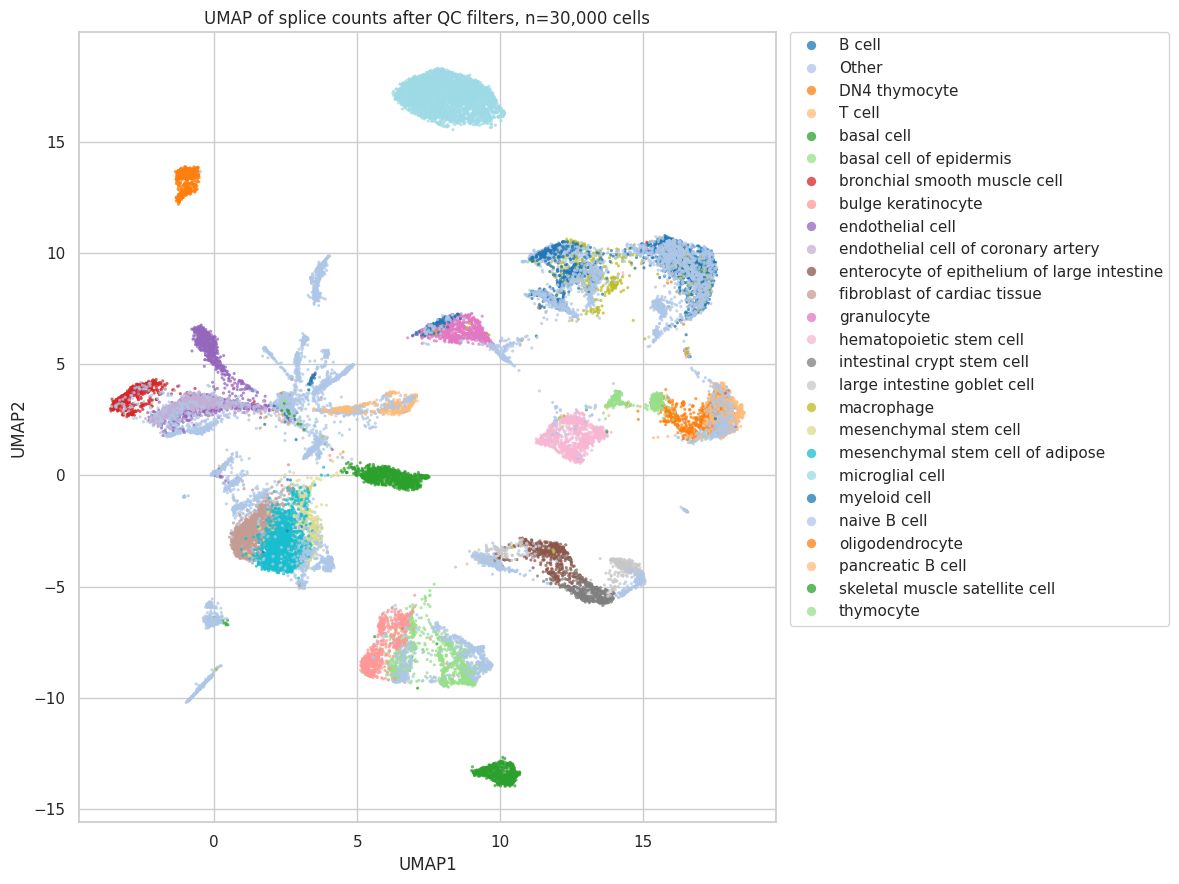

In [7]:
plt.figure(figsize=(12, 9))
if cell_type_col is not None:
    top_types = umap_df[cell_type_col].value_counts().head(25).index
    plot_df = umap_df.copy()
    plot_df[cell_type_col] = np.where(plot_df[cell_type_col].isin(top_types), plot_df[cell_type_col], 'Other')
    sns.scatterplot(
        data=plot_df,
        x='UMAP1',
        y='UMAP2',
        hue=cell_type_col,
        s=5,
        linewidth=0,
        alpha=0.75,
        palette='tab20',
    )
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, markerscale=3)
else:
    plt.scatter(umap_df['UMAP1'], umap_df['UMAP2'], s=5, alpha=0.75)
plt.title(f'UMAP of splice counts after QC filters, n={len(umap_df):,} cells')
plt.tight_layout()
plt.show()


## PSI UMAP

This embedding uses the same cells and count-filtered events retained by the UMAP QC filters. PSI is centered per event using observed PSI values only. The SVD is a randomized power-iteration SVD over an implicit centered `LinearOperator`, so the centered cell-by-event matrix is never materialized; unobserved pairs contribute zero after centering.


In [8]:
psi = sp.load_npz(PSI_NPZ).tocsr()
psi_obs = sp.load_npz(PSI_OBS_NPZ).tocsr()

# Estimate event means from observed PSI values in QC-passing cells only.
psi_qc = psi[eligible_cell_idx][:, eligible_event_idx].astype(np.float32).tocsr()
psi_qc.data = psi_qc.data / 100.0
psi_obs_qc = psi_obs[eligible_cell_idx][:, eligible_event_idx].tocsr()
observed_per_event_for_psi = np.asarray(psi_obs_qc.getnnz(axis=0)).ravel()
raw_event_mean = np.divide(
    np.asarray(psi_qc.sum(axis=0)).ravel(),
    observed_per_event_for_psi,
    out=np.zeros_like(observed_per_event_for_psi, dtype=np.float32),
    where=observed_per_event_for_psi > 0,
)
psi_event_keep = observed_per_event_for_psi > 0
psi_event_idx = eligible_event_idx[psi_event_keep]
event_psi_mean = raw_event_mean[psi_event_keep].astype(np.float32)
print(f'PSI events retained after observed-value check: {len(psi_event_idx):,} / {len(eligible_event_idx):,}')
print(f'Median observed PSI cells per retained event: {np.median(observed_per_event_for_psi[psi_event_keep]):,.0f}')
del psi_qc, psi_obs_qc

psi_sample = psi[sample_idx][:, psi_event_idx].astype(np.float32).tocsr()
psi_sample.data = psi_sample.data / 100.0
psi_obs_sample = psi_obs[sample_idx][:, psi_event_idx].astype(np.float32).tocsr()
print(f'Observed PSI sample matrix: {psi_sample.shape}, nnz={psi_sample.nnz:,}')

# Implicit centered operator: A_ij = observed_ij * (psi_ij - event_mean_j).
# matmat/rmatmat subtract the event mean only at observed entries, keeping missing pairs at zero.
def centered_psi_operator(values, observed, event_mean):
    values = values.tocsr().astype(np.float32)
    observed = observed.tocsr().astype(np.float32)
    event_mean = np.asarray(event_mean, dtype=np.float32)
    shape = values.shape

    def matmat(x):
        x = np.asarray(x, dtype=np.float32)
        return values @ x - observed @ (event_mean[:, None] * x)

    def rmatmat(x):
        x = np.asarray(x, dtype=np.float32)
        return values.T @ x - event_mean[:, None] * (observed.T @ x)

    def matvec(x):
        return matmat(np.asarray(x, dtype=np.float32)[:, None]).ravel()

    def rmatvec(x):
        return rmatmat(np.asarray(x, dtype=np.float32)[:, None]).ravel()

    return LinearOperator(shape, matvec=matvec, rmatvec=rmatvec, matmat=matmat, rmatmat=rmatmat, dtype=np.float32)


def randomized_power_svd(operator, n_components, *, n_oversamples=10, n_iter=3, random_state=13):
    rng = np.random.default_rng(random_state)
    n_random = min(operator.shape[1], n_components + n_oversamples)
    omega = rng.standard_normal((operator.shape[1], n_random), dtype=np.float32)
    q = operator.matmat(omega)
    q, _ = np.linalg.qr(q, mode='reduced')
    q = q.astype(np.float32, copy=False)

    for _ in range(n_iter):
        z = operator.rmatmat(q)
        z, _ = np.linalg.qr(z, mode='reduced')
        z = z.astype(np.float32, copy=False)
        q = operator.matmat(z)
        q, _ = np.linalg.qr(q, mode='reduced')
        q = q.astype(np.float32, copy=False)

    # Small dense matrix only: n_random x n_events, not cells x events.
    b = operator.rmatmat(q).T
    u_hat, singular_values, vt = np.linalg.svd(b, full_matrices=False)
    u = q @ u_hat[:, :n_components]
    singular_values = singular_values[:n_components]
    vt = vt[:n_components]
    return u.astype(np.float32, copy=False), singular_values.astype(np.float32, copy=False), vt.astype(np.float32, copy=False)

A_psi = centered_psi_operator(psi_sample, psi_obs_sample, event_psi_mean)
n_components = min(N_COMPONENTS, A_psi.shape[0] - 1, A_psi.shape[1] - 1)
psi_u, psi_s, psi_vt = randomized_power_svd(
    A_psi,
    n_components,
    n_oversamples=10,
    n_iter=3,
    random_state=RANDOM_STATE,
)
X_psi_svd = psi_u * psi_s[None, :]

sample_event_sum = np.asarray(psi_sample.sum(axis=0)).ravel()
sample_event_sumsq = np.asarray(psi_sample.multiply(psi_sample).sum(axis=0)).ravel()
sample_observed_per_event = np.asarray(psi_obs_sample.getnnz(axis=0)).ravel()
centered_sumsq = sample_event_sumsq - 2 * event_psi_mean * sample_event_sum + sample_observed_per_event * event_psi_mean**2
total_centered_sumsq = float(np.maximum(centered_sumsq.sum(), 0.0))
print(f'Implicit centered PSI operator: {A_psi.shape}, observed nnz={psi_sample.nnz:,}')
print(f'Power-iteration SVD captured centered sumsq ratio: {float(np.sum(psi_s**2) / total_centered_sumsq):.6f}')
print('Top centered PSI singular values:', np.array2string(psi_s[:5], precision=3))

psi_reducer = umap.UMAP(n_neighbors=30, min_dist=0.3, metric='euclidean', random_state=RANDOM_STATE, verbose=True)
psi_embedding = psi_reducer.fit_transform(X_psi_svd)

psi_umap_df = pd.DataFrame(psi_embedding, columns=['UMAP1', 'UMAP2'], index=obs.index[sample_idx])
if cell_type_col is not None:
    psi_umap_df[cell_type_col] = obs.iloc[sample_idx][cell_type_col].values
psi_umap_df.head()


PSI events retained after observed-value check: 32,450 / 32,451
Median observed PSI cells per retained event: 231


Observed PSI sample matrix: (30000, 32450), nnz=40,732,861


Implicit centered PSI operator: (30000, 32450), observed nnz=40,732,861
Power-iteration SVD captured centered sumsq ratio: 0.100723
Top centered PSI singular values: [108.897  91.246  84.291  81.924  77.981]
UMAP(min_dist=0.3, n_jobs=1, n_neighbors=30, random_state=13, verbose=True)
Mon Jun 29 14:25:31 2026 Construct fuzzy simplicial set
Mon Jun 29 14:25:31 2026 Finding Nearest Neighbors
Mon Jun 29 14:25:31 2026 Building RP forest with 14 trees


/nfs/sw/easybuild/software/Python/3.12.3-GCCcore-13.3.0/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/nfs/sw/easybuild/software/Python/3.12.3-GCCcore-13.3.0/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Mon Jun 29 14:25:31 2026 NN descent for 15 iterations


...

Mon Jun 29 14:25:38 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs


	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Jun 29 14:26:10 2026 Finished embedding


,UMAP1,UMAP2,cell_type
safe_cell_id,,,
A1-MAA000508-3_9_M-1-1,5.586309,3.890274,B cell
A10_B000794_B008549_S10,-0.384159,7.418702,B cell
A10_B001188_S262,4.213667,5.930376,B cell
A11-MAA000385-3_10_M-1-1,4.337658,5.766727,B cell
A11_B000331_S11_L004,2.326716,5.652861,B cell


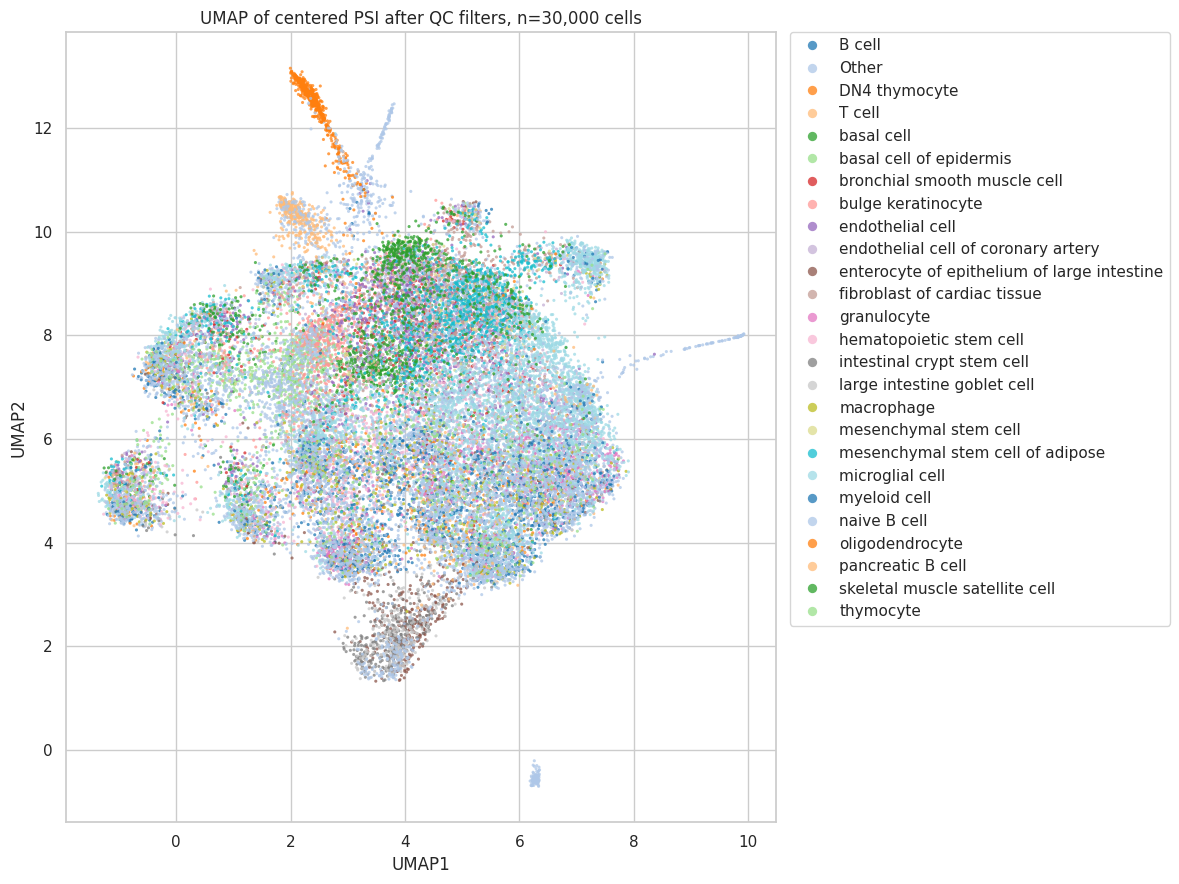

In [9]:
plt.figure(figsize=(12, 9))
if cell_type_col is not None:
    top_types = psi_umap_df[cell_type_col].value_counts().head(25).index
    plot_df = psi_umap_df.copy()
    plot_df[cell_type_col] = np.where(plot_df[cell_type_col].isin(top_types), plot_df[cell_type_col], 'Other')
    sns.scatterplot(
        data=plot_df,
        x='UMAP1',
        y='UMAP2',
        hue=cell_type_col,
        s=5,
        linewidth=0,
        alpha=0.75,
        palette='tab20',
    )
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, markerscale=3)
else:
    plt.scatter(psi_umap_df['UMAP1'], psi_umap_df['UMAP2'], s=5, alpha=0.75)
plt.title(f'UMAP of centered PSI after QC filters, n={len(psi_umap_df):,} cells')
plt.tight_layout()
plt.show()
